In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
def drop_desc(df):
    desc_cols = [c for c in df.columns if c.startswith("DESC_")]
    return df.drop(columns=desc_cols, errors="ignore")

In [3]:
def clean_date(df, col, min_date, max_date):
    d = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")
    mask = (d < min_date) | (d > max_date)
    d[mask] = pd.NaT
    d = d.fillna(d.median())
    return d

In [4]:
def drop_rare_dummies_train_test(x_train, x_test, min_count=3):
    # colonne dummy = uint8 o bool
    rare_cols = [
        col for col in x_train.columns
        if (x_train[col].dtype in ["bool"]) and (x_train[col].sum() < min_count)
    ]
    
    # rimuovo SOLO dal train
    x_train = x_train.drop(columns=rare_cols)
    
    # rimuovo le stesse colonne dal test (se presenti)
    x_test = x_test.drop(columns=[c for c in rare_cols if c in x_test.columns])
    
    return x_train, x_test, rare_cols

In [5]:
def prepare_features(df):
    df = df.copy()

    # -----------------------------
    # 0. RIMOZIONE COLONNE STRETTAMENTE CORRELATE E IENTIFICATIVI UNIVOCI ORDINE
    # -----------------------------
    df = df.drop(columns=["ID_ORDER_NUM", "VAL_COST"], errors="ignore")

    # -----------------------------
    # 1. ONE-HOT ENCODING
    # -----------------------------
    categorical_cols = [
        "ID_COMPANY", "IDS_ITEM", "ID_BUSINESS_LINE",
        "IDS_CUSTOMER", "ID_AREA_MANAGER", "ID_COUNTRY"
    ]

    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # -----------------------------
    # 2. RIMOZIONE COLONNE TESTUALI
    # -----------------------------
    df = drop_desc(df)

    # -----------------------------
    # 3. FEATURE TEMPORALI
    # -----------------------------
    df["ANNO"] = df["ID_ORDER_DATE"].dt.year
    df["TRIMESTRE"] = df["ID_ORDER_DATE"].dt.quarter
    df["MESE"] = df["ID_ORDER_DATE"].dt.month
    df["MESE_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)
    df["MESE_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)

    df["SETTIMANA"] = df["ID_ORDER_DATE"].dt.isocalendar().week.astype(int)
    df["GIORNO_SETTIMANA"] = df["ID_ORDER_DATE"].dt.weekday
    df["GIORNO_SETTIMANA_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["GIORNO_SETTIMANA_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["WEEKEND"] = df["GIORNO_SETTIMANA"].isin([5,6]).astype(int)

    df["GIORNO"] = df["ID_ORDER_DATE"].dt.dayofyear
    df["GIORNO_SIN"] = np.sin(2 * np.pi * df["GIORNO"] / 365)
    df["GIORNO_COS"] = np.cos(2 * np.pi * df["GIORNO"] / 365)

    # -----------------------------
    # 4. RIMOZIONE DATE ORIGINALI
    # -----------------------------
    df = df.drop(columns=["ID_ORDER_DATE", "ID_INVOICE_DATE"], errors="ignore")

    return df

In [6]:
def make_forecast(start_date, end_date, df_old):
    """
    Genera forecast solo per le combinazioni cliente-item esistenti nello storico.
    e applica le feature temporali tramite prepare_features().
    NON allinea le colonne con il train.
    """

    # -----------------------------
    # 1. GENERO IL CALENDARIO FUTURO
    # -----------------------------
    future_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    df_future = pd.DataFrame({"ID_ORDER_DATE": future_dates})

    # -----------------------------
    # 2. Estraggo combinazioni reali cliente-item-company-line-area-country
    # -----------------------------
    dims = df_old[[
        "ID_COMPANY",
        "IDS_ITEM",
        "ID_BUSINESS_LINE",
        "IDS_CUSTOMER",
        "ID_AREA_MANAGER",
        "ID_COUNTRY"
    ]].drop_duplicates()

    df_future = df_future.merge(dims, how="cross")

    # -----------------------------
    # 3. APPLICO LE FEATURE (prepare_features)
    # -----------------------------
    df_future = prepare_features(df_future)

    # -----------------------------
    # 4. RESTITUISCO IL DATAFRAME FUTURO
    # -----------------------------
    return df_future

In [7]:
def plot_trend(df_actual, df_forecast):
    """
    Plotta i dati storici (VAL_REVENUES) e il forecast (PREDICTED_REVENUE) insieme
    """
    df_actual = df_actual.copy()
    df_forecast = df_forecast.copy()

    # Aggiungi anno/mese a df_actual se non presenti
    if "ANNO" not in df_actual.columns:
        df_actual["ANNO"] = 2025  # placeholder

    # Calcola medie mensili
    trend_actual = df_actual.groupby(["ANNO", "MESE"])["VAL_REVENUES"].mean().reset_index()
    trend_forecast = df_forecast.groupby(["ANNO", "MESE"])["PREDICTED_REVENUE"].mean().reset_index()

    years = sorted(set(list(trend_actual["ANNO"].unique()) + list(trend_forecast["ANNO"].unique())))
    n_years = len(years)
    
    fig, axes = plt.subplots(1, n_years, figsize=(7*n_years, 5), sharey=True)
    
    if n_years == 1:
        axes = [axes]
    
    colors_actual = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, anno in enumerate(years):
        ax = axes[idx]
        
        # Dati storici
        subset_actual = trend_actual[trend_actual["ANNO"] == anno]
        if len(subset_actual) > 0:
            ax.plot(
                subset_actual["MESE"],
                subset_actual["VAL_REVENUES"],
                marker="o",
                linewidth=2.5,
                markersize=8,
                label=f"Storico {anno}",
                alpha=0.9,
                color=colors_actual[idx % len(colors_actual)]
            )
        
        # Forecast
        subset_forecast = trend_forecast[trend_forecast["ANNO"] == anno]
        if len(subset_forecast) > 0:
            ax.plot(
                subset_forecast["MESE"],
                subset_forecast["PREDICTED_REVENUE"],
                marker="s",
                linewidth=2.5,
                markersize=8,
                label=f"Forecast {anno}",
                alpha=0.9,
                color=colors_actual[idx % len(colors_actual)],
                linestyle='--'
            )
        
        ax.set_xlim(0.5, 12.5)
        ax.set_ylim(25000, 45000)
        ax.set_xlabel("Mese", fontsize=11, fontweight='bold')
        ax.set_ylabel("Revenue Media (€)", fontsize=11, fontweight='bold') if idx == 0 else None
        ax.set_title(f"Anno {anno}", fontsize=12, fontweight='bold')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels([f"{i}" for i in range(1, 13)])
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=10)
    
    fig.suptitle("Confronto Dati Storici vs Forecast", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("trend_linear_regression.png", dpi=300, bbox_inches='tight')
    plt.show()

# 1. CARICAMENTO E MERGE DATI

In [8]:
df_sales = pd.read_csv("SALES.csv")
df_company = pd.read_csv("COMPANY_LOOKUP.csv").drop_duplicates()
df_items = pd.read_csv("ITEM_LOOKUP.csv").drop_duplicates()
df_lines = pd.read_csv("ITEM_BUSINESS_LINE_LOOKUP.csv").drop_duplicates()
df_customers = pd.read_csv("CUSTOMER_LOOKUP.csv").drop_duplicates()
df_area = pd.read_csv("AREA_MANAGER_LOOKUP.csv").drop_duplicates()

df = df_sales.merge(df_company, on="ID_COMPANY", how="left")
df = df.merge(df_items, on="IDS_ITEM", how="left")
df = df.merge(df_lines, on="ID_BUSINESS_LINE", how="left")
df = df.merge(df_customers, on="IDS_CUSTOMER", how="left")
df = df.merge(df_area, on="ID_AREA_MANAGER", how="left")

# 2. PULIZIA DATE

In [9]:
min_date = pd.Timestamp("1900-01-01")
max_date = pd.Timestamp("today")

df["ID_INVOICE_DATE"] = clean_date(df, "ID_INVOICE_DATE", min_date, max_date)
df["ID_ORDER_DATE"] = clean_date(df, "ID_ORDER_DATE",   min_date, max_date)

# 3. FEATURE ENGINEERING

In [10]:
df_ml = prepare_features(df)

# 4. TRAIN/TEST SPLIT PER ANNO

In [11]:
split_idx = int(len(df_ml) * 0.9)

train = df_ml.iloc[:split_idx]
test = df_ml.iloc[split_idx:]

x_train = train.drop(columns=["VAL_REVENUES"])
y_train = train["VAL_REVENUES"]

x_test = test.drop(columns=["VAL_REVENUES"])
y_test = test["VAL_REVENUES"]

# 5. CREAZIONE MODELLO LINEARE

In [12]:
# TRASFORMAZIONE TARGET (LOG)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# RIMOZIONE DUMMY RARE
x_train, x_test, dropped_cols = drop_rare_dummies_train_test(x_train, x_test)

# SCALING
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# MODELLO LINEARE
model = LinearRegression()
model.fit(x_train_scaled, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 6. PREDIZIONE E METRICHE

In [13]:
y_pred_log = model.predict(x_test_scaled)
y_pred = np.expm1(y_pred_log)  # inversione log

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}, R2: {r2}")

# COEFFICIENTI
coeff_df = pd.DataFrame(model.coef_, index=x_train.columns, columns=['Peso_Variabile'])
print(coeff_df.sort_values(by='Peso_Variabile', ascending=False))

MAE: 3736.5135709380265, R2: 0.7017571109680318
                         Peso_Variabile
ID_COUNTRY_US                  0.286828
GIORNO                         0.235941
ID_COUNTRY_IT                  0.153257
ID_AREA_MANAGER_4D6            0.153015
ID_BUSINESS_LINE_4C7           0.149086
...                                 ...
IDS_ITEM_7479344-405MAG       -0.120235
IDS_ITEM_7195806-405MAG       -0.129026
ID_COMPANY_80640              -0.153257
IDS_ITEM_7481581-405MAG       -0.200030
MESE                          -0.229423

[68 rows x 1 columns]


In [14]:
df_future = make_forecast(
    start_date="2026-03-01",
    end_date="2027-03-01",
    df_old = df
)

In [15]:
# Aggiungo colonne mancanti
missing_cols = set(x_train.columns) - set(df_future.columns)
for col in missing_cols:
    df_future[col] = 0

# Rimuovo colonne extra
df_future = df_future[x_train.columns]

df_future_scaled = scaler.transform(df_future)
pred_log = model.predict(df_future_scaled)
df_future["PREDICTED_REVENUE"] = np.expm1(pred_log)

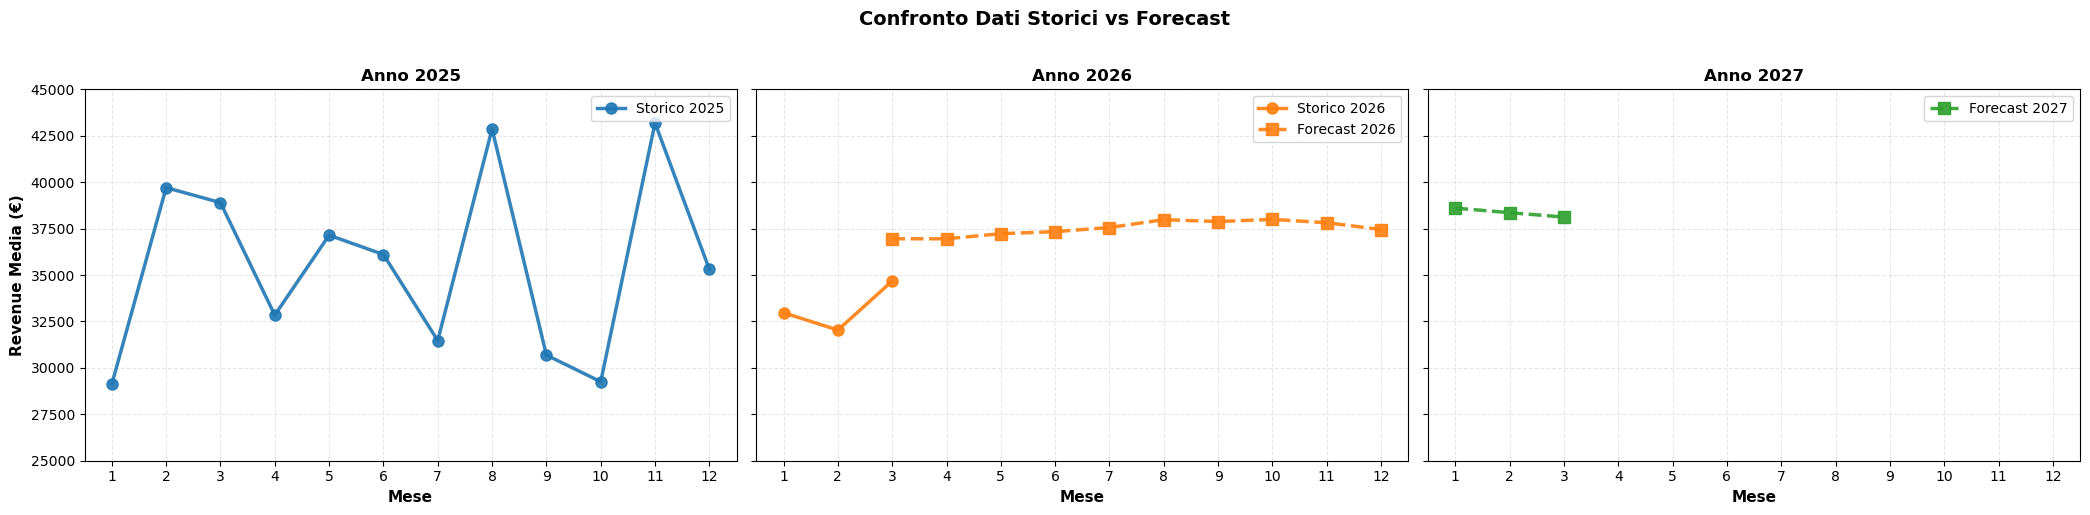

In [16]:
plot_trend(df_ml, df_future)